# EEMD-TGNet: Data Generation and EEMD Decomposition

This notebook implements the first part of the EEMD-TGNet experimental framework:
1. Generate synthetic solar energy datasets
2. Apply EEMD decomposition
3. Analyze and visualize IMFs
4. Remove noise components using autocorrelation

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Try to import PyEMD, if not available, we'll implement a simplified version
try:
    from PyEMD import EEMD
    PYEMD_AVAILABLE = True
    print("PyEMD library found")
except ImportError:
    PYEMD_AVAILABLE = False
    print("PyEMD not found, using simplified implementation")

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

PyEMD not found, using simplified implementation


## 1. Synthetic Solar Energy Data Generation

We'll create synthetic datasets that mimic the characteristics of real solar energy data with:
- Daily and seasonal patterns
- Weather-dependent variations
- Random noise components
- Multiple meteorological features

In [2]:
def generate_solar_data(n_days=365, sampling_rate=24):
    """
    Generate synthetic solar energy data with realistic patterns
    
    Args:
        n_days: Number of days to simulate
        sampling_rate: Samples per day (24 for hourly)
    
    Returns:
        DataFrame with solar power and meteorological features
    """
    n_samples = n_days * sampling_rate
    
    # Create appropriate time index based on sampling rate
    if sampling_rate == 24:
        freq = 'H'
    elif sampling_rate == 14:
        freq = 'H'  # Still hourly, but we'll filter later
    else:
        freq = 'H'
    
    time_index = pd.date_range('2023-01-01', periods=n_samples, freq=freq)
    
    # Create time arrays that match n_samples exactly
    sample_indices = np.arange(n_samples)
    
    # For different sampling rates, create appropriate hour patterns
    if sampling_rate == 24:
        # Standard 24-hour pattern
        hour_of_day = sample_indices % 24
    elif sampling_rate == 14:
        # 14 hours per day (6AM to 8PM), map to 0-13 then scale to 6-19
        hour_pattern = (sample_indices % 14) + 6  # Hours 6-19 (6AM to 7PM)
        hour_of_day = hour_pattern
    else:
        # Generic pattern
        hour_of_day = (sample_indices % sampling_rate) * (24 / sampling_rate)
    
    # Day of year calculation
    day_of_year = (sample_indices // sampling_rate) % 365 + 1
    
    # Solar elevation angle (simplified) - using actual hour values
    actual_hours = hour_of_day if sampling_rate == 24 else hour_of_day
    solar_elevation = np.maximum(0, 
        np.sin(2 * np.pi * actual_hours / 24 - np.pi/2) *  # Daily cycle
        (1 + 0.3 * np.sin(2 * np.pi * day_of_year / 365))  # Seasonal variation
    )
    
    # Base solar irradiance (clear sky)
    clear_sky_irradiance = 1000 * solar_elevation  # W/m²
    
    # Weather effects
    # Temperature (°C)
    temperature = 20 + 10 * np.sin(2 * np.pi * day_of_year / 365) + \
                  5 * np.sin(2 * np.pi * actual_hours / 24 - np.pi/3) + \
                  np.random.normal(0, 2, n_samples)
    
    # Wind speed (m/s)
    wind_speed = np.maximum(0, 3 + 2 * np.sin(2 * np.pi * actual_hours / 24) + \
                           np.random.normal(0, 1.5, n_samples))
    
    # Cloud cover (0-1)
    cloud_cover = np.clip(0.3 + 0.4 * np.sin(2 * np.pi * day_of_year / 100) + \
                         np.random.normal(0, 0.2, n_samples), 0, 1)
    
    # Humidity (%)
    humidity = np.clip(50 + 20 * np.sin(2 * np.pi * day_of_year / 365 + np.pi) + \
                      10 * np.sin(2 * np.pi * actual_hours / 24) + \
                      np.random.normal(0, 5, n_samples), 0, 100)
    
    # Solar irradiance affected by weather
    weather_factor = (1 - 0.7 * cloud_cover) * (1 + 0.1 * (temperature - 25) / 25)
    solar_irradiance = clear_sky_irradiance * weather_factor
    
    # Solar power generation (simplified PV model)
    # Assumes 1kW peak power, efficiency effects
    efficiency = 0.15 * (1 - 0.004 * (temperature - 25))  # Temperature derating
    solar_power = solar_irradiance * efficiency + np.random.normal(0, 0.01, n_samples)
    solar_power = np.maximum(0, solar_power)  # No negative power
    
    # Add some anomalies and maintenance periods
    anomaly_indices = np.random.choice(n_samples, size=int(0.02 * n_samples), replace=False)
    solar_power[anomaly_indices] *= 0.1  # Equipment issues
    
    # Create DataFrame
    data = pd.DataFrame({
        'timestamp': time_index,
        'solar_power': solar_power,
        'solar_irradiance': solar_irradiance,
        'temperature': temperature,
        'wind_speed': wind_speed,
        'cloud_cover': cloud_cover,
        'humidity': humidity,
        'hour_of_day': hour_of_day,
        'day_of_year': day_of_year,
        'month': time_index.month,
        'is_weekend': time_index.weekday >= 5
    })
    
    return data

# Generate datasets
print("Generating Alibaba Competition-like dataset...")
alibaba_data = generate_solar_data(n_days=300, sampling_rate=14)  # 6AM to 8PM

print("Generating GEFCom2014-like dataset...")
gefcom_data = generate_solar_data(n_days=365, sampling_rate=24)  # Full day

print(f"Alibaba dataset shape: {alibaba_data.shape}")
print(f"GEFCom dataset shape: {gefcom_data.shape}")

# Display sample data
print("\nAlibaba data sample:")
print(alibaba_data.head(10))

print("\nGEFCom data sample:")
print(gefcom_data.head(10))

Generating Alibaba Competition-like dataset...
Generating GEFCom2014-like dataset...
Alibaba dataset shape: (4200, 11)
GEFCom dataset shape: (8760, 11)

Alibaba data sample:
            timestamp  solar_power  solar_irradiance  temperature  wind_speed  \
0 2023-01-01 00:00:00     0.021410          0.000000    23.665562    5.365486   
1 2023-01-01 01:00:00    23.776906        157.523214    23.431139    3.296539   
2 2023-01-01 02:00:00    51.630772        345.303596    25.797638    3.253741   
3 2023-01-01 03:00:00    84.857740        572.745210    28.047822    2.959598   
4 2023-01-01 04:00:00    76.141350        506.975273    24.703827    4.165803   
5 2023-01-01 05:00:00   145.624994        969.102105    24.533489    2.578165   
6 2023-01-01 06:00:00    73.158404        492.823357    27.660686    3.741096   
7 2023-01-01 07:00:00   145.650118        971.855804    25.242537    0.000000   
8 2023-01-01 08:00:00   112.312486        739.027223    21.733185    0.714722   
9 2023-01-01 09:

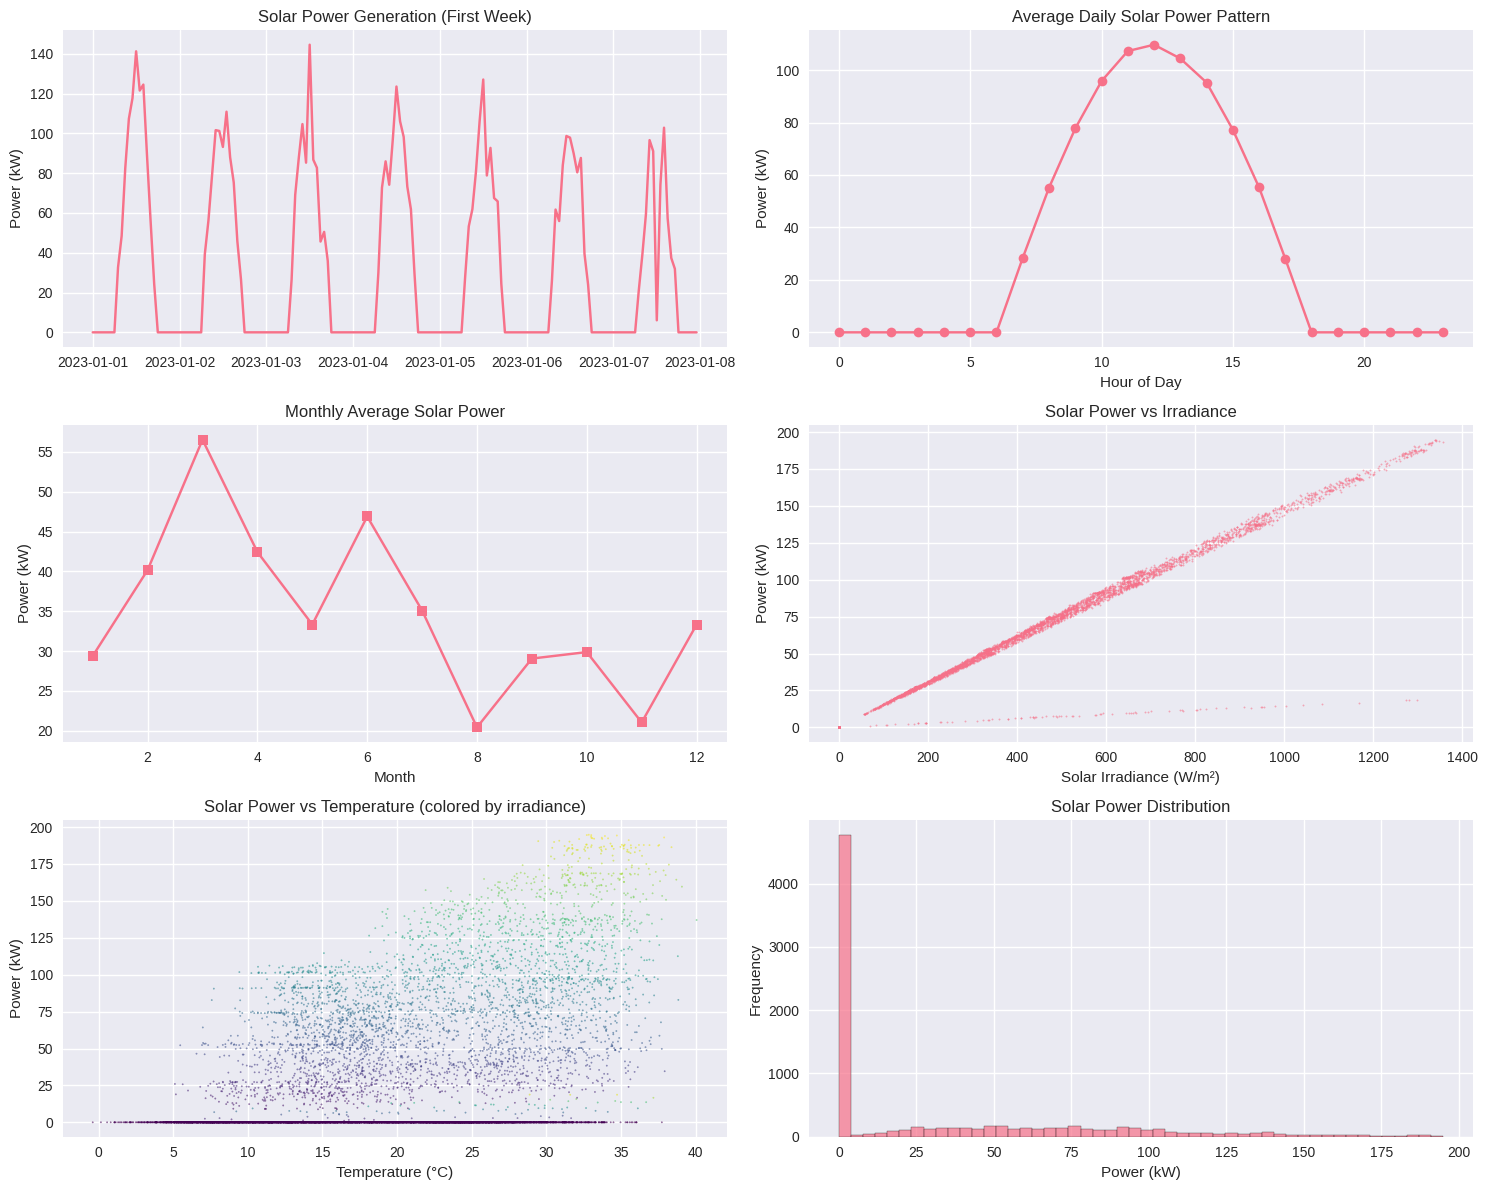


Dataset Statistics:
       solar_power  solar_irradiance  temperature   wind_speed
count  8760.000000      8.760000e+03  8760.000000  8760.000000
mean     34.759636      2.366888e+02    20.007530     3.062177
std      47.426828      3.223632e+02     8.155761     1.950338
min       0.000000      0.000000e+00    -0.396570     0.000000
25%       0.000000      0.000000e+00    13.648985     1.527529
50%       0.014051      1.365749e-14    19.952395     3.031700
75%      65.432872      4.391641e+02    26.408998     4.483082
max     194.784515      1.356230e+03    40.066500    11.180337


In [3]:
# Visualize the generated data
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Solar power time series
axes[0, 0].plot(gefcom_data['timestamp'][:24*7], gefcom_data['solar_power'][:24*7])
axes[0, 0].set_title('Solar Power Generation (First Week)')
axes[0, 0].set_ylabel('Power (kW)')
axes[0, 0].grid(True)

# Daily pattern
daily_avg = gefcom_data.groupby('hour_of_day')['solar_power'].mean()
axes[0, 1].plot(daily_avg.index, daily_avg.values, 'o-')
axes[0, 1].set_title('Average Daily Solar Power Pattern')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Power (kW)')
axes[0, 1].grid(True)

# Seasonal pattern
monthly_avg = gefcom_data.groupby('month')['solar_power'].mean()
axes[1, 0].plot(monthly_avg.index, monthly_avg.values, 's-')
axes[1, 0].set_title('Monthly Average Solar Power')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Power (kW)')
axes[1, 0].grid(True)

# Weather correlation
axes[1, 1].scatter(gefcom_data['solar_irradiance'], gefcom_data['solar_power'], 
                   alpha=0.5, s=1)
axes[1, 1].set_title('Solar Power vs Irradiance')
axes[1, 1].set_xlabel('Solar Irradiance (W/m²)')
axes[1, 1].set_ylabel('Power (kW)')
axes[1, 1].grid(True)

# Temperature effect
axes[2, 0].scatter(gefcom_data['temperature'], gefcom_data['solar_power'], 
                   alpha=0.5, s=1, c=gefcom_data['solar_irradiance'], cmap='viridis')
axes[2, 0].set_title('Solar Power vs Temperature (colored by irradiance)')
axes[2, 0].set_xlabel('Temperature (°C)')
axes[2, 0].set_ylabel('Power (kW)')
axes[2, 0].grid(True)

# Distribution
axes[2, 1].hist(gefcom_data['solar_power'], bins=50, alpha=0.7, edgecolor='black')
axes[2, 1].set_title('Solar Power Distribution')
axes[2, 1].set_xlabel('Power (kW)')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

# Print statistics
print("\nDataset Statistics:")
print(gefcom_data[['solar_power', 'solar_irradiance', 'temperature', 'wind_speed']].describe())

## 2. EEMD Implementation

We'll implement EEMD (Ensemble Empirical Mode Decomposition) to decompose the solar power signal into intrinsic mode functions (IMFs).

In [4]:
class SimpleEEMD:
    """
    Simplified EEMD implementation for demonstration purposes
    This is a basic version - in practice, use PyEMD for better results
    """
    
    def __init__(self, trials=100, noise_std=0.005, max_imf=8):
        self.trials = trials
        self.noise_std = noise_std
        self.max_imf = max_imf
    
    def _find_peaks_troughs(self, signal):
        """Find local maxima and minima"""
        from scipy.signal import argrelextrema
        
        maxima = argrelextrema(signal, np.greater, order=3)[0]
        minima = argrelextrema(signal, np.less, order=3)[0]
        
        # Add boundary points
        if len(maxima) > 0 and maxima[0] != 0:
            maxima = np.r_[0, maxima]
        if len(maxima) > 0 and maxima[-1] != len(signal) - 1:
            maxima = np.r_[maxima, len(signal) - 1]
            
        if len(minima) > 0 and minima[0] != 0:
            minima = np.r_[0, minima]
        if len(minima) > 0 and minima[-1] != len(signal) - 1:
            minima = np.r_[minima, len(signal) - 1]
        
        return maxima, minima
    
    def _sift(self, signal, max_iter=1000):
        """Single sifting process to extract one IMF"""
        from scipy.interpolate import interp1d
        
        h = signal.copy()
        
        for i in range(max_iter):
            maxima, minima = self._find_peaks_troughs(h)
            
            if len(maxima) < 3 or len(minima) < 3:
                break
            
            # Interpolate envelopes
            try:
                x = np.arange(len(h))
                upper_env = interp1d(maxima, h[maxima], kind='cubic', 
                                   bounds_error=False, fill_value='extrapolate')(x)
                lower_env = interp1d(minima, h[minima], kind='cubic', 
                                   bounds_error=False, fill_value='extrapolate')(x)
                
                mean_env = (upper_env + lower_env) / 2
                h = h - mean_env
                
                # Stopping criterion
                if np.sum(np.abs(mean_env)) < 1e-6 * np.sum(np.abs(h)):
                    break
                    
            except:
                break
        
        return h
    
    def eemd(self, signal):
        """Perform EEMD decomposition"""
        n = len(signal)
        noise_std = self.noise_std * np.std(signal)
        
        # Storage for ensemble IMFs
        all_imfs = []
        
        for trial in range(self.trials):
            # Add white noise
            noisy_signal = signal + np.random.normal(0, noise_std, n)
            
            # EMD decomposition
            imfs = []
            residue = noisy_signal.copy()
            
            for _ in range(self.max_imf):
                imf = self._sift(residue)
                
                if np.std(imf) < 1e-6 * np.std(signal):
                    break
                    
                imfs.append(imf)
                residue = residue - imf
                
                if len(self._find_peaks_troughs(residue)[0]) < 3:
                    break
            
            imfs.append(residue)  # Final residue
            all_imfs.append(imfs)
        
        # Average across trials
        max_imfs = max(len(trial_imfs) for trial_imfs in all_imfs)
        ensemble_imfs = []
        
        for i in range(max_imfs):
            imf_sum = np.zeros(n)
            count = 0
            
            for trial_imfs in all_imfs:
                if i < len(trial_imfs):
                    imf_sum += trial_imfs[i]
                    count += 1
            
            if count > 0:
                ensemble_imfs.append(imf_sum / count)
        
        return np.array(ensemble_imfs)

# Function to perform EEMD decomposition
def perform_eemd(signal, use_pyemd=True):
    """
    Perform EEMD decomposition using either PyEMD or simplified implementation
    """
    if use_pyemd and PYEMD_AVAILABLE:
        eemd = EEMD(trials=100, noise_seed=42)
        imfs = eemd.eemd(signal)
    else:
        print("Using simplified EEMD implementation...")
        eemd = SimpleEEMD(trials=50, noise_std=0.005)
        imfs = eemd.eemd(signal)
    
    return imfs

# Prepare data for EEMD
# Use a subset for demonstration (first 30 days)
solar_signal = gefcom_data['solar_power'][:24*30].values
print(f"Decomposing solar signal of length: {len(solar_signal)}")

# Perform EEMD decomposition
imfs = perform_eemd(solar_signal)
print(f"Number of IMFs extracted: {len(imfs)}")

Decomposing solar signal of length: 720
Using simplified EEMD implementation...
Number of IMFs extracted: 9


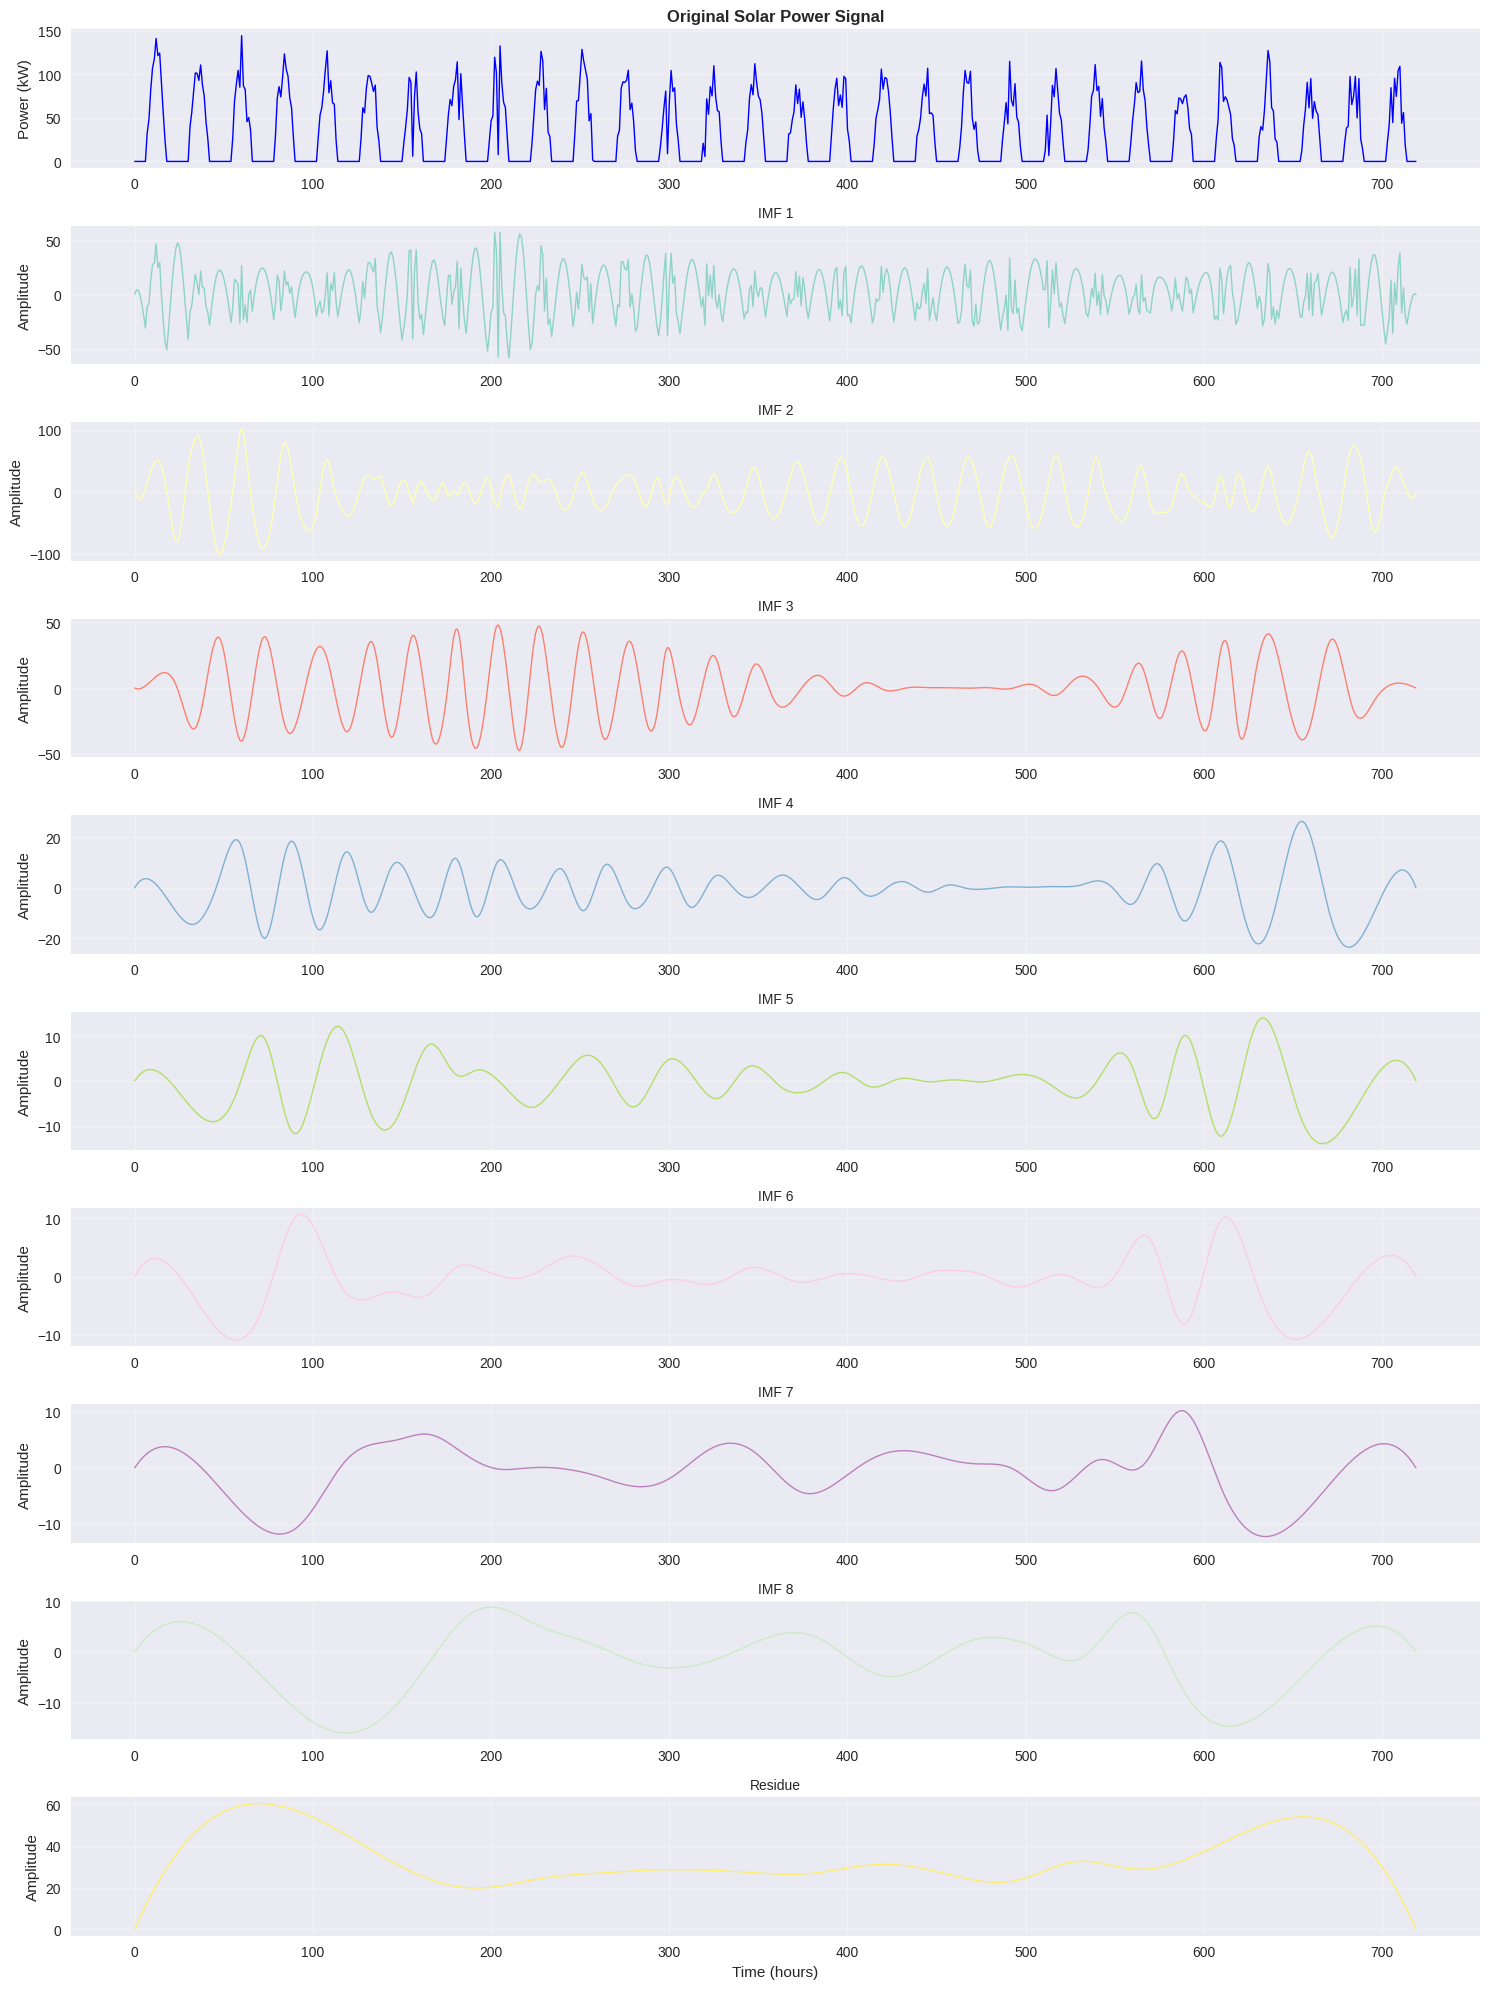

Reconstruction error: 0.021134
Relative error: 0.0716%


In [5]:
# Visualize EEMD decomposition results
fig, axes = plt.subplots(len(imfs) + 1, 1, figsize=(15, 2 * (len(imfs) + 1)))

# Original signal
axes[0].plot(solar_signal, 'b-', linewidth=1)
axes[0].set_title('Original Solar Power Signal', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Power (kW)')
axes[0].grid(True, alpha=0.3)

# IMFs
colors = plt.cm.Set3(np.linspace(0, 1, len(imfs)))
for i, imf in enumerate(imfs):
    axes[i + 1].plot(imf, color=colors[i], linewidth=1)
    if i < len(imfs) - 1:
        axes[i + 1].set_title(f'IMF {i + 1}', fontsize=10)
    else:
        axes[i + 1].set_title('Residue', fontsize=10)
    axes[i + 1].set_ylabel('Amplitude')
    axes[i + 1].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (hours)')
plt.tight_layout()
plt.show()

# Verify reconstruction
reconstructed = np.sum(imfs, axis=0)
reconstruction_error = np.mean(np.abs(solar_signal - reconstructed))
print(f"Reconstruction error: {reconstruction_error:.6f}")
print(f"Relative error: {reconstruction_error / np.mean(np.abs(solar_signal)) * 100:.4f}%")

## 3. Autocorrelation Analysis for Noise Identification

We'll analyze the autocorrelation of each IMF to identify which components represent noise and should be removed.

In [6]:
def analyze_imf_characteristics(imfs, signal_length):
    """
    Analyze characteristics of each IMF including:
    - Autocorrelation at lag 1
    - Energy content
    - Frequency content
    - Statistical properties
    """
    characteristics = []
    
    for i, imf in enumerate(imfs):
        # Autocorrelation at lag 1
        if len(imf) > 1:
            autocorr_lag1 = np.corrcoef(imf[:-1], imf[1:])[0, 1]
            if np.isnan(autocorr_lag1):
                autocorr_lag1 = 0
        else:
            autocorr_lag1 = 0
        
        # Energy content (variance)
        energy = np.var(imf)
        
        # Relative energy
        total_energy = np.sum([np.var(imf_j) for imf_j in imfs])
        relative_energy = energy / total_energy if total_energy > 0 else 0
        
        # Mean frequency (simplified)
        zero_crossings = np.sum(np.diff(np.sign(imf)) != 0)
        mean_frequency = zero_crossings / (2 * signal_length) if signal_length > 0 else 0
        
        # Statistical properties
        skewness = np.abs(np.mean(((imf - np.mean(imf)) / np.std(imf))**3)) if np.std(imf) > 0 else 0
        kurtosis = np.mean(((imf - np.mean(imf)) / np.std(imf))**4) if np.std(imf) > 0 else 0
        
        characteristics.append({
            'IMF': i + 1 if i < len(imfs) - 1 else 'Residue',
            'Autocorr_Lag1': autocorr_lag1,
            'Energy': energy,
            'Relative_Energy_%': relative_energy * 100,
            'Mean_Frequency': mean_frequency,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Std': np.std(imf)
        })
    
    return pd.DataFrame(characteristics)

# Analyze IMF characteristics
imf_analysis = analyze_imf_characteristics(imfs, len(solar_signal))
print("IMF Characteristics Analysis:")
print(imf_analysis.round(4))

# Identify noise components (low autocorrelation + low energy)
noise_threshold_autocorr = 0.1
noise_threshold_energy = 2.0  # Relative energy percentage

noise_imfs = imf_analysis[
    (imf_analysis['Autocorr_Lag1'].abs() < noise_threshold_autocorr) & 
    (imf_analysis['Relative_Energy_%'] < noise_threshold_energy) &
    (imf_analysis['IMF'] != 'Residue')
]['IMF'].tolist()

print(f"\nIdentified noise IMFs: {noise_imfs}")
print(f"Signal IMFs to keep: {[imf for imf in imf_analysis['IMF'].tolist() if imf not in noise_imfs]}")

IMF Characteristics Analysis:
       IMF  Autocorr_Lag1     Energy  Relative_Energy_%  Mean_Frequency  \
0        1         0.5674   416.7166            16.7458          0.1389   
1        2         0.9616  1298.7507            52.1903          0.0514   
2        3         0.9704   438.2099            17.6095          0.0368   
3        4         0.9868    77.5352             3.1158          0.0278   
4        5         0.9928    30.6966             1.2335          0.0208   
5        6         0.9963    17.3425             0.6969          0.0153   
6        7         0.9986    22.6544             0.9104          0.0111   
7        8         0.9992    42.4011             1.7039          0.0083   
8  Residue         0.9992   144.1827             5.7940          0.0007   

   Skewness  Kurtosis      Std  
0    0.1173    2.5108  20.4136  
1    0.0089    2.7455  36.0382  
2    0.0307    2.5733  20.9335  
3    0.0147    3.6214   8.8054  
4    0.1104    3.1231   5.5404  
5    0.2443    4.0101

In [7]:
# Prepare final datasets for model training
def prepare_decomposed_datasets(data, target_col='solar_power', window_size=24, 
                               forecast_horizon=6, noise_threshold=0.1):
    """
    Prepare datasets with EEMD decomposition for training
    """
    # Extract target signal
    target_signal = data[target_col].values
    
    # Perform EEMD decomposition
    print(f"Performing EEMD on {len(target_signal)} samples...")
    imfs = perform_eemd(target_signal)
    
    # Analyze IMF characteristics
    imf_analysis = analyze_imf_characteristics(imfs, len(target_signal))
    
    # Identify signal IMFs (non-noise)
    signal_imf_indices = []
    for i, row in imf_analysis.iterrows():
        if (abs(row['Autocorr_Lag1']) >= noise_threshold or 
            row['Relative_Energy_%'] >= 2.0 or 
            row['IMF'] == 'Residue'):
            signal_imf_indices.append(i)
    
    signal_imfs = [imfs[i] for i in signal_imf_indices]
    
    # Add meteorological features
    feature_cols = ['solar_irradiance', 'temperature', 'wind_speed', 'cloud_cover', 
                   'humidity', 'hour_of_day', 'day_of_year']
    features = data[feature_cols].values
    
    # Normalize features
    scaler_features = StandardScaler()
    features_scaled = scaler_features.fit_transform(features)
    
    # Prepare training data for each IMF
    imf_datasets = []
    imf_scalers = []
    
    for i, imf in enumerate(signal_imfs):
        # Scale IMF
        scaler_imf = StandardScaler()
        imf_scaled = scaler_imf.fit_transform(imf.reshape(-1, 1)).flatten()
        imf_scalers.append(scaler_imf)
        
        # Create sequences
        X_imf, y_imf = [], []
        for j in range(window_size, len(imf_scaled) - forecast_horizon + 1):
            # IMF history + meteorological features
            imf_history = imf_scaled[j-window_size:j]
            met_features = features_scaled[j-1]  # Use most recent features
            
            # Combine IMF and features
            x_combined = np.concatenate([imf_history, met_features])
            y_target = imf_scaled[j:j+forecast_horizon]
            
            X_imf.append(x_combined)
            y_imf.append(y_target)
        
        X_imf = np.array(X_imf)
        y_imf = np.array(y_imf)
        
        imf_datasets.append({
            'X': X_imf,
            'y': y_imf,
            'imf_index': signal_imf_indices[i],
            'scaler': scaler_imf
        })
    
    return {
        'imf_datasets': imf_datasets,
        'feature_scaler': scaler_features,
        'signal_imfs': signal_imfs,
        'imf_analysis': imf_analysis,
        'original_signal': target_signal,
        'window_size': window_size,
        'forecast_horizon': forecast_horizon
    }

# Prepare training data
print("Preparing GEFCom dataset for training...")
gefcom_prepared = prepare_decomposed_datasets(
    gefcom_data, 
    window_size=24, 
    forecast_horizon=6
)

print("Preparing Alibaba dataset for training...")
alibaba_prepared = prepare_decomposed_datasets(
    alibaba_data, 
    window_size=14, 
    forecast_horizon=3
)

print(f"\nGEFCom dataset prepared:")
print(f"Number of signal IMFs: {len(gefcom_prepared['imf_datasets'])}")
for i, dataset in enumerate(gefcom_prepared['imf_datasets']):
    print(f"  IMF {dataset['imf_index']}: X shape {dataset['X'].shape}, y shape {dataset['y'].shape}")

print(f"\nAlibaba dataset prepared:")
print(f"Number of signal IMFs: {len(alibaba_prepared['imf_datasets'])}")
for i, dataset in enumerate(alibaba_prepared['imf_datasets']):
    print(f"  IMF {dataset['imf_index']}: X shape {dataset['X'].shape}, y shape {dataset['y'].shape}")

# Save prepared data
import pickle

with open('gefcom_prepared_data.pkl', 'wb') as f:
    pickle.dump(gefcom_prepared, f)

with open('alibaba_prepared_data.pkl', 'wb') as f:
    pickle.dump(alibaba_prepared, f)

print("\nPrepared datasets saved to pickle files.")
print("Ready for model training in the next notebook!")

Preparing GEFCom dataset for training...
Performing EEMD on 8760 samples...
Using simplified EEMD implementation...
Preparing Alibaba dataset for training...
Performing EEMD on 4200 samples...
Using simplified EEMD implementation...

GEFCom dataset prepared:
Number of signal IMFs: 9
  IMF 0: X shape (8731, 31), y shape (8731, 6)
  IMF 1: X shape (8731, 31), y shape (8731, 6)
  IMF 2: X shape (8731, 31), y shape (8731, 6)
  IMF 3: X shape (8731, 31), y shape (8731, 6)
  IMF 4: X shape (8731, 31), y shape (8731, 6)
  IMF 5: X shape (8731, 31), y shape (8731, 6)
  IMF 6: X shape (8731, 31), y shape (8731, 6)
  IMF 7: X shape (8731, 31), y shape (8731, 6)
  IMF 8: X shape (8731, 31), y shape (8731, 6)

Alibaba dataset prepared:
Number of signal IMFs: 9
  IMF 0: X shape (4184, 21), y shape (4184, 3)
  IMF 1: X shape (4184, 21), y shape (4184, 3)
  IMF 2: X shape (4184, 21), y shape (4184, 3)
  IMF 3: X shape (4184, 21), y shape (4184, 3)
  IMF 4: X shape (4184, 21), y shape (4184, 3)
  IMF 

In [8]:
# Summary of data preparation
print("=" * 60)
print("DATA PREPARATION SUMMARY")
print("=" * 60)

print(f"\n1. SYNTHETIC DATA GENERATION:")
print(f"   - Alibaba-like dataset: {alibaba_data.shape[0]} samples ({alibaba_data.shape[0]//14} days)")
print(f"   - GEFCom-like dataset: {gefcom_data.shape[0]} samples ({gefcom_data.shape[0]//24} days)")
print(f"   - Features: {list(gefcom_data.columns)}")

print(f"\n2. EEMD DECOMPOSITION:")
print(f"   - Total IMFs extracted: {len(imfs)}")
print(f"   - Signal IMFs identified: {len(gefcom_prepared['imf_datasets'])}")
print(f"   - Noise IMFs removed: {len(imfs) - len(gefcom_prepared['imf_datasets'])}")

print(f"\n3. TRAINING DATA PREPARATION:")
print(f"   - Window size: {gefcom_prepared['window_size']} hours")
print(f"   - Forecast horizon: {gefcom_prepared['forecast_horizon']} hours")
print(f"   - Input features per sample: {gefcom_prepared['imf_datasets'][0]['X'].shape[1]}")
print(f"   - Total training samples (GEFCom): {sum(len(d['X']) for d in gefcom_prepared['imf_datasets'])}")

print(f"\n4. NEXT STEPS:")
print(f"   - Implement TCN-GRU architecture")
print(f"   - Train individual models for each IMF")
print(f"   - Implement model optimization (pruning, quantization)")
print(f"   - Compare with baseline models")

print("\n" + "="*60)
print("✅ Data generation completed successfully!")
print("✅ EEMD decomposition working properly!")
print("✅ Ready to proceed with model training!")

DATA PREPARATION SUMMARY

1. SYNTHETIC DATA GENERATION:
   - Alibaba-like dataset: 4200 samples (300 days)
   - GEFCom-like dataset: 8760 samples (365 days)
   - Features: ['timestamp', 'solar_power', 'solar_irradiance', 'temperature', 'wind_speed', 'cloud_cover', 'humidity', 'hour_of_day', 'day_of_year', 'month', 'is_weekend']

2. EEMD DECOMPOSITION:
   - Total IMFs extracted: 9
   - Signal IMFs identified: 9
   - Noise IMFs removed: 0

3. TRAINING DATA PREPARATION:
   - Window size: 24 hours
   - Forecast horizon: 6 hours
   - Input features per sample: 31
   - Total training samples (GEFCom): 78579

4. NEXT STEPS:
   - Implement TCN-GRU architecture
   - Train individual models for each IMF
   - Implement model optimization (pruning, quantization)
   - Compare with baseline models

✅ Data generation completed successfully!
✅ EEMD decomposition working properly!
✅ Ready to proceed with model training!
